# **01_understanding_data.ipynb - Brain Tumor MRI Deep Learning Project**

In [1]:
import os
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

## 1. **Import Libraties**

In [2]:
# Display settings
plt.style.use("ggplot")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. **Project Path**

In [ ]:
import os
_nb_dir = Path(os.getcwd())
if _nb_dir.name == 'notebooks':
    PROJECT_ROOT = _nb_dir.parent
else:
    PROJECT_ROOT = _nb_dir
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
BRAIN_DATA_DIR = RAW_DATA_DIR  # Data nam truc tiep trong data/raw/
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

print(f"Raw data path      : {RAW_DATA_DIR}")
print(f"Brain dataset path : {BRAIN_DATA_DIR}")
print(f"Processed path     : {PROCESSED_DATA_DIR}")

Raw data path      : data\raw
Brain dataset path : data\raw\brain_data
Processed path     : data\processed


Nếu thấy đường dẫn sai thì dùng câu lệnh **PROJECT_ROOT = Path.cwd()** 

In [12]:
print(os.getcwd())

y:\code\deep_learning\brain\Brain-Tumor-Mri-Deep-Learning


In [11]:
# Check dataset structure
if not BRAIN_DATA_DIR.exists():
    print("Dataset directory does not exist.")
else:
    print("Dataset directory found.\n")

    folders = sorted([
        folder.name
        for folder in BRAIN_DATA_DIR.iterdir()
        if folder.is_dir()
    ])

    print("Tumor Classes / MRI Sequences:")
    for idx, folder in enumerate(folders, start=1):
        print(f"{idx:02d}. {folder}")

Dataset directory found.

Tumor Classes / MRI Sequences:
01. Astrocytoma T1
02. Astrocytoma T1C+
03. Astrocytoma T2
04. Ependymoma T1
05. Ependymoma T1C+
06. Ependymoma T2
07. Glioma T1
08. Glioma T1C+
09. Glioma T2
10. Hemangiopericytoma T1
11. Hemangiopericytoma T1C+
12. Hemangiopericytoma T2
13. Meningioma T1
14. Meningioma T1C+
15. Meningioma T2
16. Neurocytoma T1
17. Neurocytoma T1C+
18. Neurocytoma T2
19. Normal T1
20. Normal T1C+
21. Normal T2
22. Oligodendroglioma T1
23. Oligodendroglioma T1C+
24. Oligodendroglioma T2
25. Other T1
26. Other T1C+
27. Other T2
28. Schwannoma T1
29. Schwannoma T1C+
30. Schwannoma T2


## **3. Infomation dataset**

In [13]:
image_extensions = [".jpg", ".jpeg", ".png", ".bmp"]

class_counts = {}

for folder in BRAIN_DATA_DIR.iterdir():

    if folder.is_dir():

        image_count = len([
            file for file in folder.iterdir()
            if file.suffix.lower() in image_extensions
        ])

        class_counts[folder.name] = image_count

In [14]:
# Convert to DataFrame
df_counts = pd.DataFrame({
    "Class": list(class_counts.keys()),
    "Images": list(class_counts.values())
})

df_counts = df_counts.sort_values(
    by="Images",
    ascending=False
)

print(df_counts)

                      Class  Images
13          Meningioma T1C+     977
25               Other T1C+     756
12            Meningioma T1     636
28          Schwannoma T1C+     564
7               Glioma T1C+     549
6                 Glioma T1     522
14            Meningioma T2     458
1          Astrocytoma T1C+     441
18                Normal T1     415
24                 Other T1     412
8                 Glioma T2     405
0            Astrocytoma T1     396
20                Normal T2     379
4           Ependymoma T1C+     374
26                 Other T2     365
27            Schwannoma T1     363
5             Ependymoma T2     350
3             Ependymoma T1     313
29            Schwannoma T2     309
10  Hemangiopericytoma T1C+     307
2            Astrocytoma T2     281
19              Normal T1C+     264
16         Neurocytoma T1C+     254
21     Oligodendroglioma T1     221
22   Oligodendroglioma T1C+     192
15           Neurocytoma T1     190
9     Hemangiopericytoma T1 

## 4. **Visualize class Distribution**

In [29]:
import seaborn as sns 
sns.set_theme(style="darkgrid", palette="pastel")
plt.rcParams.update({
    "grid.color": "0.3",
    "axes.facecolor": "#1c1c1c",
    "figure.facecolor": "#121212",
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})

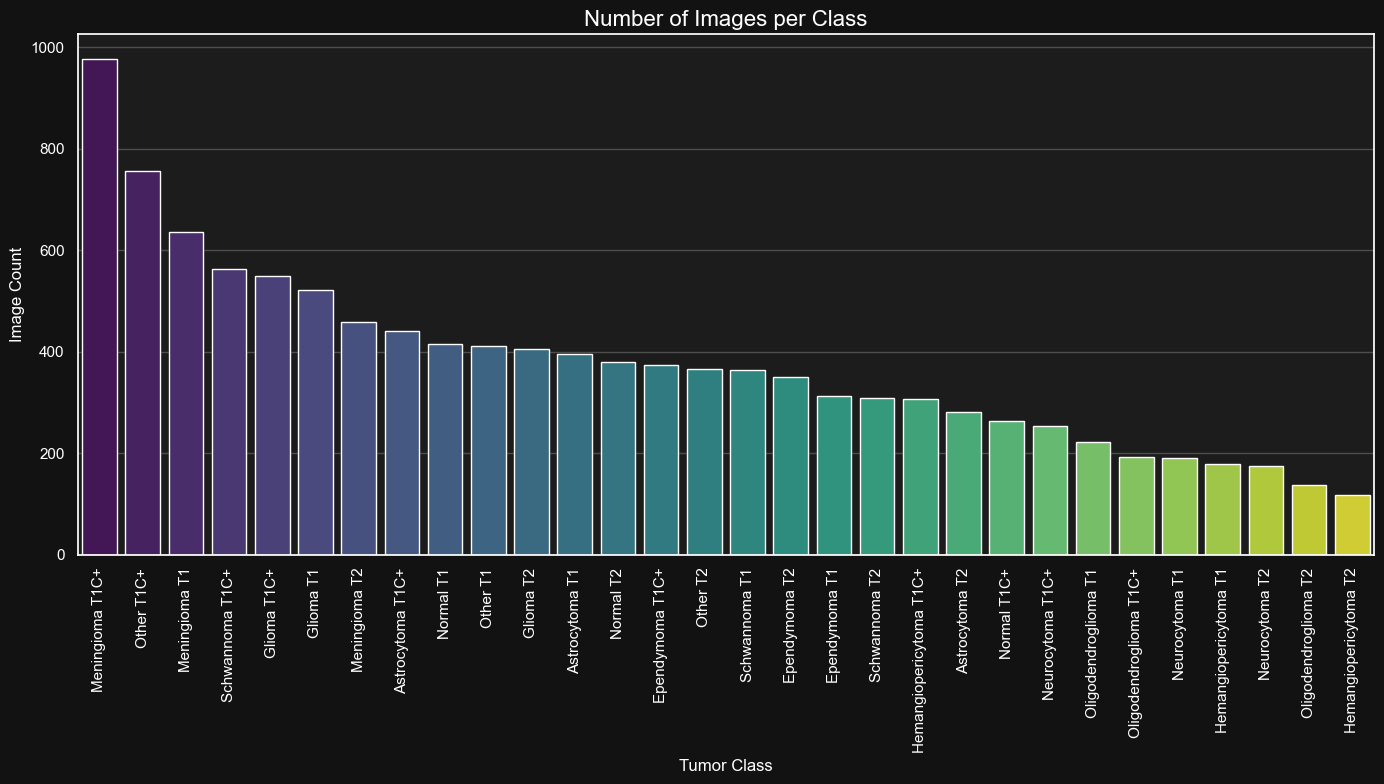

In [33]:
plt.figure(figsize=(14, 8))

# Sử dụng sns.barplot
ax = sns.barplot(
    data=df_counts, 
    x="Class", 
    y="Images", 
    palette="viridis",
    hue='Class'
)


plt.xticks(rotation=90)
plt.title("Number of Images per Class", fontsize=16)
plt.xlabel("Tumor Class", fontsize=12)
plt.ylabel("Image Count", fontsize=12)

plt.tight_layout()
plt.savefig('reports/images/information_data/number_of_images_per_class_dark.png')
plt.show()

In [16]:
# Total number of images 
total_images = df_counts["Images"].sum()

print("=" * 50)
print(f"TOTAL IMAGES : {total_images}")
print("=" * 50)

TOTAL IMAGES : 11300


## 5. **Display Sample Images**

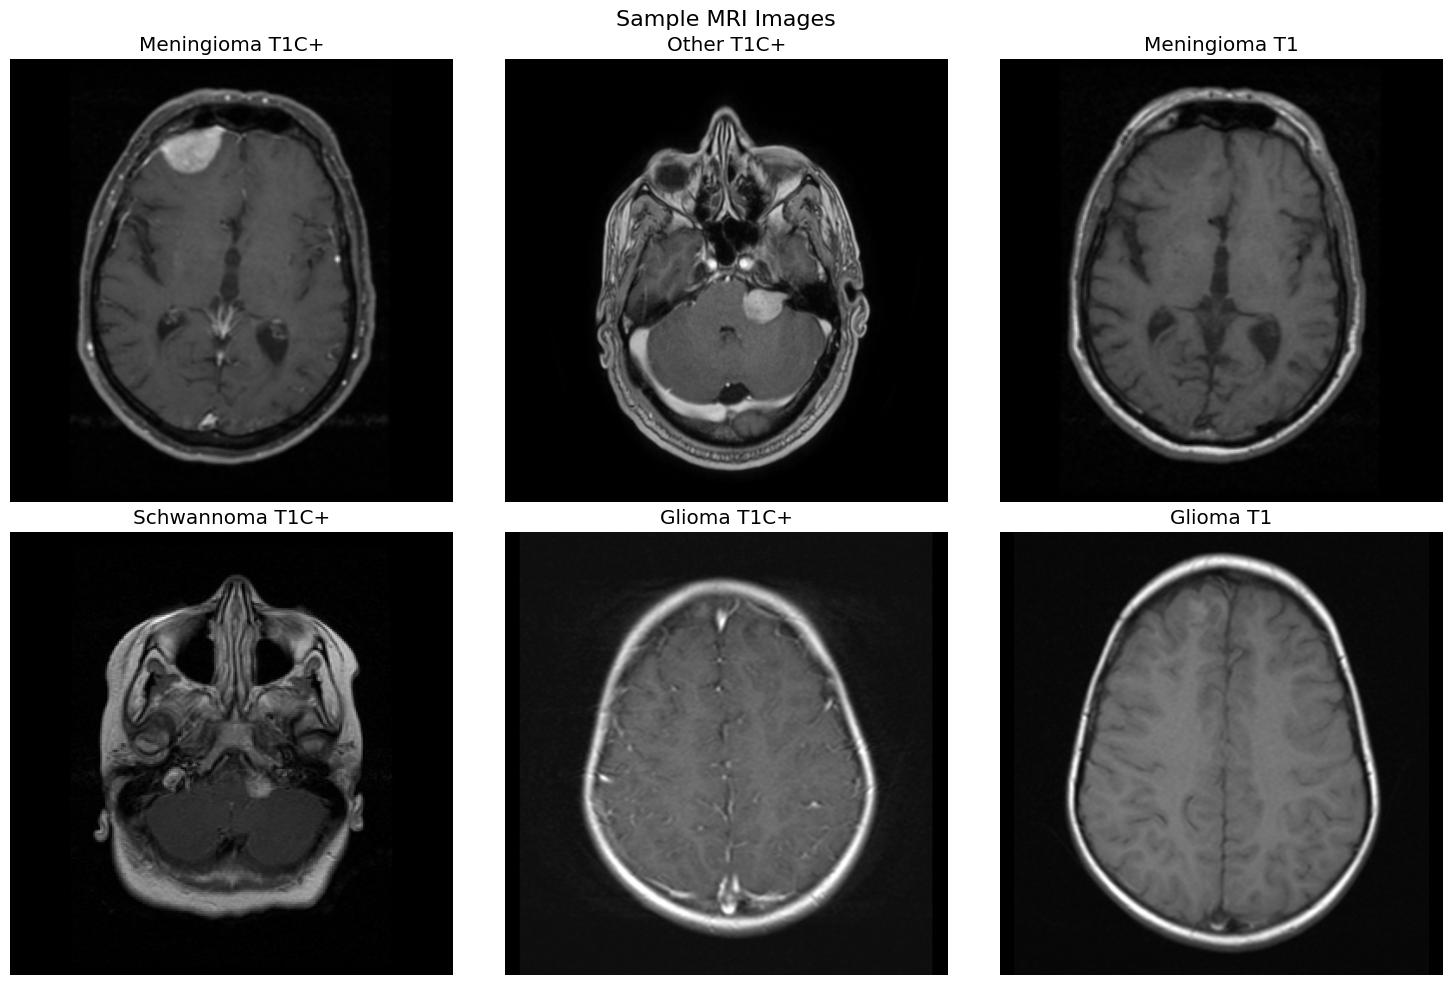

In [28]:
sample_classes = df_counts["Class"].head(6).tolist()

plt.figure(figsize=(15, 10))

for idx, class_name in enumerate(sample_classes):

    class_dir = BRAIN_DATA_DIR / class_name

    image_files = [
        file for file in class_dir.iterdir()
        if file.suffix.lower() in image_extensions
    ]

    if len(image_files) == 0:
        continue

    sample_image_path = image_files[0]

    image = Image.open(sample_image_path)

    plt.subplot(2, 3, idx + 1)
    plt.imshow(image, cmap="gray")
    plt.title(class_name)
    plt.axis("off")

plt.suptitle("Sample MRI Images", fontsize=16)

plt.tight_layout()
plt.savefig('reports/images/information_data/sample_mri_images.png')
plt.show()

In [18]:
# analyze image size 
image_sizes = []

for folder in BRAIN_DATA_DIR.iterdir():

    if folder.is_dir():

        image_files = [
            file for file in folder.iterdir()
            if file.suffix.lower() in image_extensions
        ]

        for image_path in image_files[:20]:

            try:
                image = Image.open(image_path)
                image_sizes.append(image.size)

            except Exception as e:
                print(f"Error reading {image_path.name}: {e}")

In [19]:
# Create DataFrame
df_sizes = pd.DataFrame(
    image_sizes,
    columns=["Width", "Height"]
)

print(df_sizes.describe())

       Width  Height
count  600.0   600.0
mean   512.0   512.0
std      0.0     0.0
min    512.0   512.0
25%    512.0   512.0
50%    512.0   512.0
75%    512.0   512.0
max    512.0   512.0


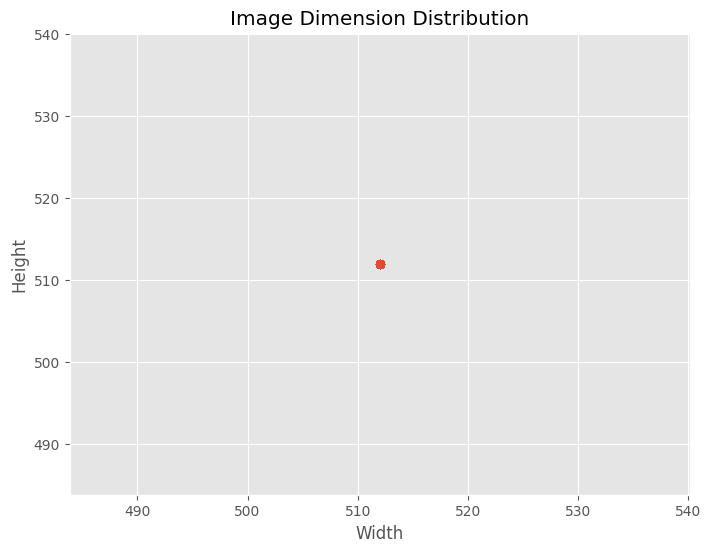

In [20]:
# Visualize image dimensions
plt.figure(figsize=(8, 6))

plt.scatter(
    df_sizes["Width"],
    df_sizes["Height"],
    alpha=0.6
)

plt.title("Image Dimension Distribution")
plt.xlabel("Width")
plt.ylabel("Height")

plt.show()

In [21]:
# check dataset sample
max_images = df_counts["Images"].max()
min_images = df_counts["Images"].min()

imbalance_ratio = max_images / min_images

print("=" * 50)
print(f"MAX IMAGES      : {max_images}")
print(f"MIN IMAGES      : {min_images}")
print(f"IMBALANCE RATIO : {imbalance_ratio:.2f}")
print("=" * 50)

MAX IMAGES      : 977
MIN IMAGES      : 118
IMBALANCE RATIO : 8.28


## 6. **Load DATA.json**

In [25]:
json_path = BRAIN_DATA_DIR / "DATA.json"

if json_path.exists():

    with open(json_path, "r", encoding="utf-8") as file:
        metadata = json.load(file)

    print("DATA.json loaded successfully.")

    if isinstance(metadata, dict):

        print("\nMetadata keys:")
        print(list(metadata.keys()))

    elif isinstance(metadata, list):

        print(f"\nTotal records: {len(metadata)}")

else:

    print("DATA.json not found.")
    print(f"Expected path: {json_path.resolve()}")

DATA.json loaded successfully.

Metadata keys:
['Astrocytoma T1\\T1 - Anaplastic astrocytoma (pineal region) 001.jpg', 'Astrocytoma T1\\T1 - Anaplastic astrocytoma (pineal region) 002.jpg', 'Astrocytoma T1\\T1 - Anaplastic astrocytoma (pineal region) 003.jpg', 'Astrocytoma T1\\T1 - Anaplastic astrocytoma (pineal region) 004.jpg', 'Astrocytoma T1\\T1 - Anaplastic astrocytoma frontal , ventricle 001.jpg', 'Astrocytoma T1\\T1 - Anaplastic astrocytoma frontal , ventricle 002.jpg', 'Astrocytoma T1\\T1 - Anaplastic astrocytoma frontal , ventricle 003.jpg', 'Astrocytoma T1\\T1 - Anaplastic astrocytoma NOS 004.jpg', 'Astrocytoma T1\\T1 - Anaplastic astrocytoma NOS 005.jpg', 'Astrocytoma T1\\T1 - Anaplastic astrocytoma NOS 006.jpg', 'Astrocytoma T1\\T1 - Anaplastic astrocytoma parietal , ventricle 001.jpg', 'Astrocytoma T1\\T1 - Anaplastic astrocytoma parietal , ventricle 002.jpg', 'Astrocytoma T1\\T1 - Anaplastic astrocytoma parietal , ventricle 003.jpg', 'Astrocytoma T1\\T1 - Anaplastic astro

In [24]:
print(list(RAW_DATA_DIR.iterdir()))

[WindowsPath('data/raw/archive.zip'), WindowsPath('data/raw/brain_data')]


In [26]:
print("\nDATA UNDERSTANDING SUMMARY")
print("=" * 60)

print(f"Total Classes : {len(df_counts)}")
print(f"Total Images  : {total_images}")

print("\nTop 5 Largest Classes:")
print(df_counts.head())

print("\nTop 5 Smallest Classes:")
print(df_counts.tail())

print("\nNotebook completed successfully.")


DATA UNDERSTANDING SUMMARY
Total Classes : 30
Total Images  : 11300

Top 5 Largest Classes:
              Class  Images
13  Meningioma T1C+     977
25       Other T1C+     756
12    Meningioma T1     636
28  Schwannoma T1C+     564
7       Glioma T1C+     549

Top 5 Smallest Classes:
                    Class  Images
15         Neurocytoma T1     190
9   Hemangiopericytoma T1     178
17         Neurocytoma T2     174
23   Oligodendroglioma T2     137
11  Hemangiopericytoma T2     118

Notebook completed successfully.
